In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import math


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dropout, LSTM, Dense, Layer, LayerNormalization, BatchNormalization, Conv1D, MaxPooling1D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping

import yfinance as yf

In [2]:
def apply_ssa_trend(series, window = 15, lookback = 60):
    n_total = len(series)
    result = np.zeros(n_total)
    
    result[:lookback] = series[:lookback]
    
    for t in range(lookback, n_total):
        sub_series = series[t - lookback + 1 : t + 1]
        
        N = len(sub_series)
        L = window
        K = N - L + 1
        X = np.column_stack([sub_series[i:i+L] for i in range(K)])
        
        U, Sigma, VT = np.linalg.svd(X, full_matrices=False)
        
        X1 = Sigma[0] * np.outer(U[:, 0], VT[0, :])
        
        n = N - 1
        vals = [X1[i, n-i] for i in range(max(0, n-K+1), min(n+1, L))]
        result[t] = np.mean(vals)
        
    return result

# Period must be one of: 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
def get_dataset_columns(ticker, period = "1y", lookback = 60):
    df = yf.Tickers(ticker).history(period = period)
    # vix_data = yf.Tickers("^VIX").history(period = period, progress=False)
    df.columns = df.columns.droplevel(1)
    # vix_data.columns = vix_data.columns.droplevel(1)
    df = df.ffill().dropna()

    df = df.drop(['Stock Splits', 'Dividends'], axis=1)
    df['Yesterday_Close'] = df['Close'].shift(1)
    df['Close_Trend'] = apply_ssa_trend(df['Yesterday_Close'].values, window=15, lookback=lookback)
    df['Trend_Diff'] = df['Yesterday_Close'] - df['Close_Trend']

    # df['Target'] = ((df['Close'] - df['Yesterday_Close'])  * 100 / df['Yesterday_Close'])
    # df['Target'] = np.log(df['Close'] / df['Yesterday_Close']) * 100
    df['Target'] = df['Close']
    df = df.drop(df.index[0])
    
    df = df.drop(['High', 'Low', 'Volume', 'Close'], axis=1)

    feature_cols = ["Open", "Yesterday_Close", "Close_Trend", "Trend_Diff"]
    target_col = ["Target"]

    return df[lookback:], feature_cols, target_col

feature_scalers = {}
target_scalers = {}

def scale_dataset(df, ticker, feature_cols, target_col, test_size=0.2, scale_target=False):
    train_size = int(len(df) * (1 - test_size))
    df_train = df.iloc[:train_size]

    if ticker not in feature_scalers:
        f_scaler = StandardScaler()
        f_scaler.fit(df_train[feature_cols])
        feature_scalers[ticker] = f_scaler

        if scale_target:
            t_scaler = StandardScaler()
            t_scaler.fit(df_train[target_col]) 
            target_scalers[ticker] = t_scaler

    df[feature_cols] = feature_scalers[ticker].transform(df[feature_cols])
    if scale_target:
        df[target_col] = target_scalers[ticker].transform(df[target_col])

    data_x = df[feature_cols].values
    data_y = df[target_col].values

    return data_x, data_y    

def get_full_dataset(tickers, period="1y", window_size=60, test_size=0.2):
    X_total, y_total = [], []
    
    for ticker in tickers:
        df, feature_cols, target_col = get_dataset_columns(ticker, period=period, lookback=window_size)
        data_x, data_y = scale_dataset(df, ticker, feature_cols, target_col, test_size, scale_target=True)
        
        for i in range(len(df) - window_size):
            X_total.append(data_x[i : i + window_size])
            y_total.append(data_y[i + window_size])

    X_data = np.array(X_total)
    y_data = np.array(y_total)

    nan_mask = np.isnan(X_data).any(axis=(1, 2))
    X_data = X_data[~nan_mask]
    y_data = y_data[~nan_mask] 

    print(f"NaN Deleted: {np.sum(nan_mask)}")
    
    test_first_index = int(len(X_data) * (1 - test_size))
    X_train, X_test = X_data[:test_first_index], X_data[test_first_index:]
    y_train, y_test = y_data[:test_first_index], y_data[test_first_index:]

    print("""
    X_train Shape : {}
    X_test Shape : {}
    y_train Shape : {}
    y_test Shape : {}
    """.format(X_train.shape, X_test.shape, y_train.shape, y_test.shape))
    
    return X_train, X_test, y_train, y_test

In [3]:
window_size = 40

APPL_X_train, APPL_X_test, APPL_y_train, APPL_y_test = get_full_dataset(
    ["AAPL"],
    period = "3y",
    window_size = window_size, 
    test_size = 0.2
)

MSFT_X_train, MSFT_X_test, MSFT_y_train, MSFT_y_test = get_full_dataset(
    ["MSFT"],
    period = "3y",
    window_size = window_size, 
    test_size = 0.2
)

GOOGL_X_train, GOOGL_X_test, GOOGL_y_train, GOOGL_y_test = get_full_dataset(
    ["GOOGL"],
    period = "3y",
    window_size = window_size, 
    test_size = 0.2
)

AMZN_X_train, AMZN_X_test, AMZN_y_train, AMZN_y_test = get_full_dataset(
    ["AMZN"],
    period = "3y",
    window_size = window_size, 
    test_size = 0.2
)

NVDA_X_train, NVDA_X_test, NVDA_y_train, NVDA_y_test = get_full_dataset(
    ["NVDA"],
    period = "3y",
    window_size = window_size, 
    test_size = 0.2
)

[*********************100%***********************]  1 of 1 completed


NaN Deleted: 0

    X_train Shape : (536, 40, 4)
    X_test Shape : (135, 40, 4)
    y_train Shape : (536, 1)
    y_test Shape : (135, 1)
    


[*********************100%***********************]  1 of 1 completed


NaN Deleted: 0

    X_train Shape : (536, 40, 4)
    X_test Shape : (135, 40, 4)
    y_train Shape : (536, 1)
    y_test Shape : (135, 1)
    


[*********************100%***********************]  1 of 1 completed


NaN Deleted: 0

    X_train Shape : (536, 40, 4)
    X_test Shape : (135, 40, 4)
    y_train Shape : (536, 1)
    y_test Shape : (135, 1)
    


[*********************100%***********************]  1 of 1 completed


NaN Deleted: 0

    X_train Shape : (536, 40, 4)
    X_test Shape : (135, 40, 4)
    y_train Shape : (536, 1)
    y_test Shape : (135, 1)
    


[*********************100%***********************]  1 of 1 completed

NaN Deleted: 0

    X_train Shape : (536, 40, 4)
    X_test Shape : (135, 40, 4)
    y_train Shape : (536, 1)
    y_test Shape : (135, 1)
    


In [23]:
def get_CNN_LSTM_hybrid(window_size=60, feature_num=7):
    # Dropout rate from the paper
    dropout_rate = 0.2
    
    # 1. Input Layer
    input_layer = Input(shape=(window_size, feature_num), name="Input")
    
    # 2. CNN Section: Two convolutional layers
    # Kernel size = 3, stride = 1 as specified in the paper
    x = Conv1D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu', name="Conv1D_1")(input_layer)
    x = LayerNormalization(name="LayerNormalization_1")(x)
    x = Conv1D(filters=64, kernel_size=3, strides=1, padding='same', activation='relu', name="Conv1D_2")(x)
    x = LayerNormalization(name="LayerNormalization_2")(x)
    
    # 3. Max-Pooling layer follows the CNN layers
    x = MaxPooling1D(pool_size=2, name="Max_Pooling")(x)
    
    # 4. LSTM Section: Two LSTM layers (64 and 32 units)
    # First LSTM layer must return sequences to pass to the second
    x = LSTM(64, return_sequences=True, name="LSTM_1")(x)
    x = Dropout(dropout_rate, name="Dropout_1")(x)
    x = LayerNormalization(name="BatchNormalization_1")(x)
    
    # Second LSTM layer provides the final temporal summary
    x = LSTM(32, return_sequences=False, name="LSTM_2")(x)
    x = Dropout(dropout_rate, name="Dropout_2")(x)
    x = LayerNormalization(name="BatchNormalization_2")(x)
    
    # 5. Output Section: Two fully connected layers
    x = Dense(16, activation="relu", name="FullyConnected_1")(x)
    output_layer = Dense(1, activation="linear", name="Output")(x)

    model = Model(inputs=input_layer, outputs=output_layer, name='SSA_CNN_LSTM_Hybrid')

    # Optimization: Adam optimizer with learning rate 0.001
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, 
                  loss='mse', 
                  metrics=['mae', tf.keras.metrics.RootMeanSquaredError()])
    return model

In [24]:
feature_num = 4

APPL_CNN_LSTM_model = get_CNN_LSTM_hybrid(window_size, feature_num)
APPL_CNN_LSTM_model.summary()

MSFT_CNN_LSTM_model = get_CNN_LSTM_hybrid(window_size, feature_num)
MSFT_CNN_LSTM_model.summary()

GOOGL_CNN_LSTM_model = get_CNN_LSTM_hybrid(window_size, feature_num)
GOOGL_CNN_LSTM_model.summary()

AMZN_CNN_LSTM_model = get_CNN_LSTM_hybrid(window_size, feature_num)
AMZN_CNN_LSTM_model.summary()

NVDA_CNN_LSTM_model = get_CNN_LSTM_hybrid(window_size, feature_num)
NVDA_CNN_LSTM_model.summary()

Model: "SSA_CNN_LSTM_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 40, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_1 (Conv1D)               │ (None, 40, 64)         │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LayerNormalization_1            │ (None, 40, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_2 (Conv1D)               │ (None, 40, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LayerNormalization_2            │ (None, 40, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pooling (MaxPooling1D)      │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_1 (LSTM)                   │ (None, 20, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization_1            │ (None, 20, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization_2            │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FullyConnected_1 (Dense)        │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,617 (232.88 KB)

 Trainable params: 59,617 (232.88 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "SSA_CNN_LSTM_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 40, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_1 (Conv1D)               │ (None, 40, 64)         │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LayerNormalization_1            │ (None, 40, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_2 (Conv1D)               │ (None, 40, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LayerNormalization_2            │ (None, 40, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pooling (MaxPooling1D)      │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_1 (LSTM)                   │ (None, 20, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization_1            │ (None, 20, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNormalization_2            │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FullyConnected_1 (Dense)        │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,617 (232.88 KB)

 Trainable params: 59,617 (232.88 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
earlyStopping_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=5,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
)

APPL_CNN_LSTM_model.fit(
    APPL_X_train, 
    APPL_y_train, 
    epochs = 50, 
    batch_size = 32,
    validation_data = (APPL_X_test, APPL_y_test),
    callbacks = [earlyStopping_callback]
)

MSFT_CNN_LSTM_model.fit(
    MSFT_X_train, 
    MSFT_y_train, 
    epochs = 50, 
    batch_size = 32,
    validation_data = (MSFT_X_test, MSFT_y_test),
    callbacks = [earlyStopping_callback]
)

GOOGL_CNN_LSTM_model.fit(
    GOOGL_X_train, 
    GOOGL_y_train, 
    epochs = 50, 
    batch_size = 32,
    validation_data = (GOOGL_X_test, GOOGL_y_test),
    callbacks = [earlyStopping_callback]
)

AMZN_CNN_LSTM_model.fit(
    AMZN_X_train, 
    AMZN_y_train, 
    epochs = 50, 
    batch_size = 32,
    validation_data = (AMZN_X_test, AMZN_y_test),
    callbacks = [earlyStopping_callback]
)

NVDA_CNN_LSTM_model.fit(
    NVDA_X_train, 
    NVDA_y_train, 
    epochs = 50, 
    batch_size = 32,
    validation_data = (NVDA_X_test, NVDA_y_test),
    callbacks = [earlyStopping_callback]
)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.4899 - mae: 0.5191 - root_mean_squared_error: 0.6999 - val_loss: 1.4339 - val_mae: 1.0538 - val_root_mean_squared_error: 1.1975
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2118 - mae: 0.3565 - root_mean_squared_error: 0.4602 - val_loss: 1.1633 - val_mae: 0.9452 - val_root_mean_squared_error: 1.0786
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1974 - mae: 0.3443 - root_mean_squared_error: 0.4443 - val_loss: 1.2973 - val_mae: 1.0439 - val_root_mean_squared_error: 1.1390
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1509 - mae: 0.3033 - root_mean_squared_error: 0.3884 - val_loss: 1.1437 - val_mae: 0.9890 - val_root_mean_squared_error: 1.0695
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1442 - mae: 0.2953 - root_mean_squared_error: 0.3797 - val_loss: 1.3281 - val_mae: 1.0624 - val_root_mean_squared_error: 1.1524
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - lo

In [26]:
# AAPL
APPL_loss, APPL_mae, APPL_rmse = APPL_CNN_LSTM_model.evaluate(APPL_X_test, APPL_y_test)
print(f"AAPL mse: {APPL_loss}")
print(f"AAPL mae: {APPL_mae}")
print(f"AAPL rmse: {APPL_rmse}")
print("-" * 20)

# MSFT
MSFT_loss, MSFT_mae, MSFT_rmse = MSFT_CNN_LSTM_model.evaluate(MSFT_X_test, MSFT_y_test)
print(f"MSFT mse: {MSFT_loss}")
print(f"MSFT mae: {MSFT_mae}")
print(f"MSFT rmse: {MSFT_rmse}")
print("-" * 20)

# GOOGL
GOOGL_loss, GOOGL_mae, GOOGL_rmse = GOOGL_CNN_LSTM_model.evaluate(GOOGL_X_test, GOOGL_y_test)
print(f"GOOGL mse: {GOOGL_loss}")
print(f"GOOGL mae: {GOOGL_mae}")
print(f"GOOGL rmse: {GOOGL_rmse}")
print("-" * 20)

# AMZN
AMZN_loss, AMZN_mae, AMZN_rmse = AMZN_CNN_LSTM_model.evaluate(AMZN_X_test, AMZN_y_test)
print(f"AMZN mse: {AMZN_loss}")
print(f"AMZN mae: {AMZN_mae}")
print(f"AMZN rmse: {AMZN_rmse}")
print("-" * 20)

# NVDA
NVDA_loss, NVDA_mae, NVDA_rmse = NVDA_CNN_LSTM_model.evaluate(NVDA_X_test, NVDA_y_test)
print(f"NVDA mse: {NVDA_loss}")
print(f"NVDA mae: {NVDA_mae}")
print(f"NVDA rmse: {NVDA_rmse}")
print("-" * 20)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1370 - mae: 0.9878 - root_mean_squared_error: 1.0663 
AAPL mse: 1.1370095014572144
AAPL mae: 0.9877856373786926
AAPL rmse: 1.066306471824646
--------------------
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1057 - mae: 0.2570 - root_mean_squared_error: 0.3251 
MSFT mse: 0.10569294542074203
MSFT mae: 0.25704172253608704
MSFT rmse: 0.3251045048236847
--------------------
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18.2238 - mae: 3.8428 - root_mean_squared_error: 4.2689
GOOGL mse: 18.22383689880371
GOOGL mae: 3.8428072929382324
GOOGL rmse: 4.2689385414123535
--------------------
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0674 - mae: 0.2068 - root_mean_squared_error: 0.2597 
AMZN mse: 0.06744581460952759
AMZN mae: 0.2067636102437973
AMZN rmse: 0.25970330834388733
--------------------
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0356 - mae: 0.1508 - root_mean_squared_error: 0.1888 
NVDA mse: 0.03563452884554863
NVDA mae: 0.150835171341

In [27]:
models = {
    "AAPL": APPL_CNN_LSTM_model,
    "MSFT": MSFT_CNN_LSTM_model,
    "GOOGL": GOOGL_CNN_LSTM_model,
    "AMZN": AMZN_CNN_LSTM_model,
    "NVDA": NVDA_CNN_LSTM_model,
}

actual = {
    "AAPL": APPL_y_test,
    "MSFT": MSFT_y_test,
    "GOOGL": GOOGL_y_test,
    "AMZN": AMZN_y_test,
    "NVDA": NVDA_y_test,
}

predictions = {
    "AAPL": APPL_CNN_LSTM_model.predict(APPL_X_test),
    "MSFT": MSFT_CNN_LSTM_model.predict(MSFT_X_test),
    "GOOGL": GOOGL_CNN_LSTM_model.predict(GOOGL_X_test),
    "AMZN": AMZN_CNN_LSTM_model.predict(AMZN_X_test),
    "NVDA": NVDA_CNN_LSTM_model.predict(NVDA_X_test),
}

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


In [ ]:
initial_cash = 10000
cash = initial_cash
shares = 0
tickers_5 = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]

for ticker in tickers_5:
    actual_df_raw = actual[ticker]
    prediction_df_raw = predictions[ticker]

    actual_df = target_scalers[ticker].inverse_transform(actual_df_raw)
    prediction_df = target_scalers[ticker].inverse_transform(prediction_df_raw)

    prices_history = []
    preds_history = []

    previous = prediction_df[0][0]

    for price_array, pred_array in zip(actual_df, prediction_df):
        price = price_array[0]
        pred = pred_array[0]
        
        prices_history.append(price)
        preds_history.append(pred)
        
        dif = ((pred - previous) / previous) * 100

        if dif > 0.05:
            signal = 1
        elif dif < -0.05:
            signal = -1
        else:
            signal = 0

        if signal == 1 and cash > price:
            share = cash // price
            shares += share
            cash -= share * price
            print(f"Buying {ticker} : {shares}, cash : {cash}, dif : {dif}")
        elif signal == -1 and shares > 0:
            cash += shares * price
            shares = 0
            print(f"Selling {ticker} : {shares}, cash : {cash}, dif : {dif}")
        
        previous = price
            
    cash += shares * price
    print(f"***** End of {ticker}, Cash: {cash:.2f} *****")
    shares = 0

    plt.figure(figsize=(12, 6))
    plt.plot(prices_history, label='Actual Price', color='blue', alpha=0.7)
    plt.plot(preds_history, label='Predicted Price', color='red', linestyle='--', alpha=0.8)
    plt.title(f"{ticker} Price vs Prediction")
    plt.xlabel("Time Steps (Test Data)")
    plt.ylabel("Price ($)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Day 0 | Buying NVDA: 11.0 shares, Dif: 4.220%, Cash : 11.752853393554688
Day 3 | Buying AMZN: 9.0 shares, Dif: 0.823%, Cash : 6.769989013671875
Day 5 | Selling AMZN: 9.0 shares, Cash : 2085.5899505615234
Day 9 | Buying AMZN: 9.0 shares, Dif: 1.756%, Cash : 71.29997253417969
Day 20 | Selling AMZN: 9.0 shares, Cash : 2162.269989013672
Day 21 | Buying MSFT: 4.0 shares, Dif: 0.956%, Cash : 10.9227294921875
Day 21 | Buying AMZN: 9.0 shares, Dif: 0.551%, Cash : 39.71002197265625
Day 22 | Selling AMZN: 9.0 shares, Cash : 2183.870071411133
Day 24 | Buying AAPL: 8.0 shares, Dif: 0.733%, Cash : 163.2608642578125
Day 24 | Buying AMZN: 9.0 shares, Dif: 1.835%, Cash : 114.32009887695312
Day 25 | Selling AAPL: 8.0 shares, Cash : 2032.258544921875
Day 26 | Selling MSFT: 4.0 shares, Cash : 2068.5115966796875
Day 27 | Selling AMZN: 9.0 shares, Cash : 2220.7701263427734
Day 29 | Buying AMZN: 5.0 shares, Dif: 0.376%, Cash : 1064.6201477050781
Day 30 | Buying MSFT: 2.0 shares, Dif: 0.358%, Cash : 1034.586

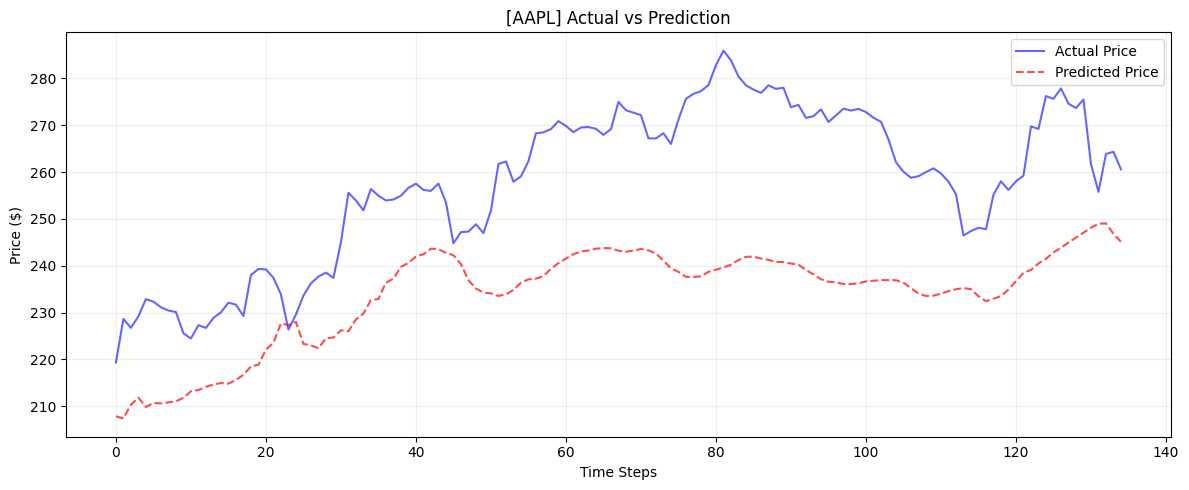

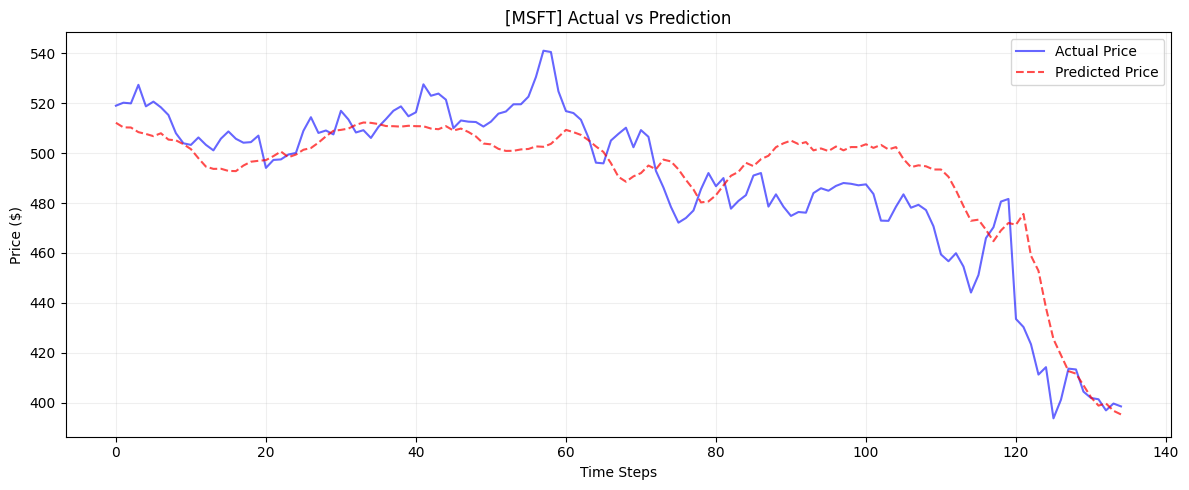

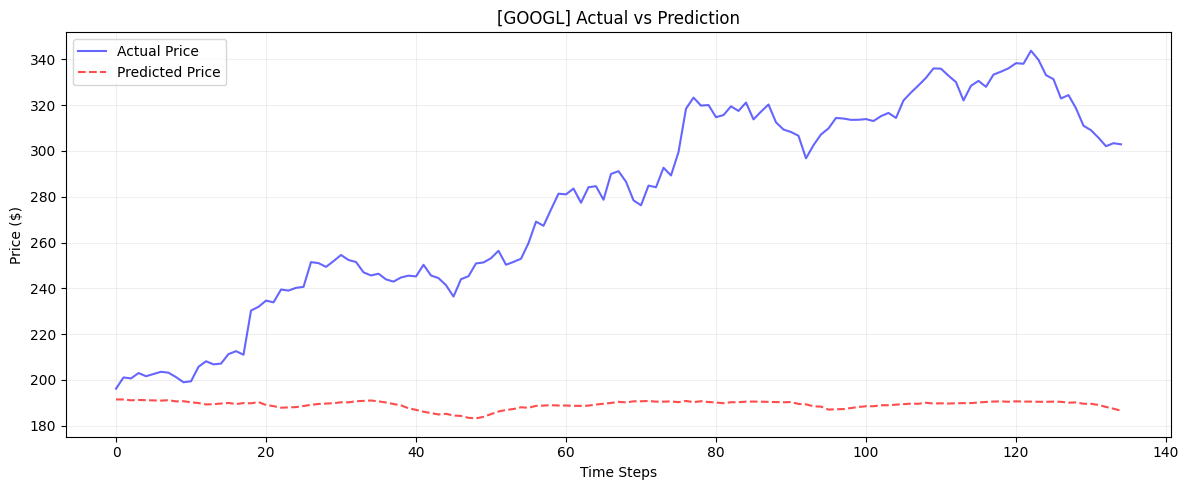

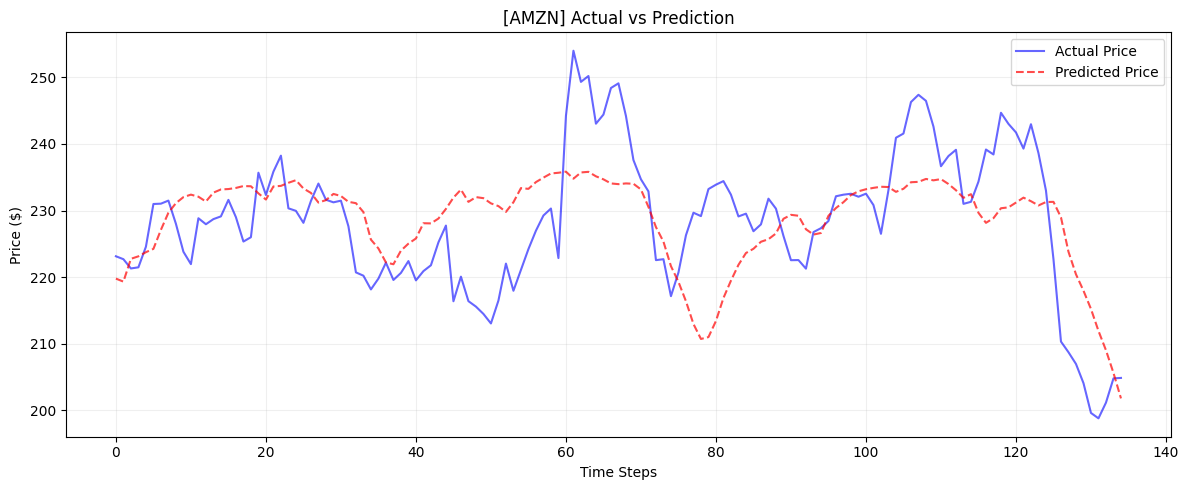

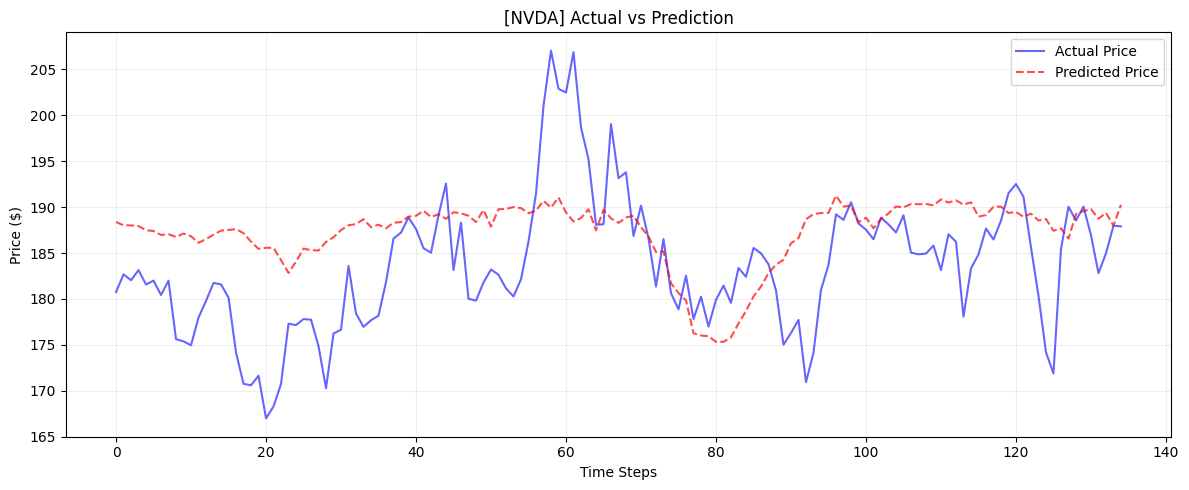

--- 최종 결과 요약 ---
초기 자본: $10000
최종 자산: $11258.02
누적 수익률: 12.58%


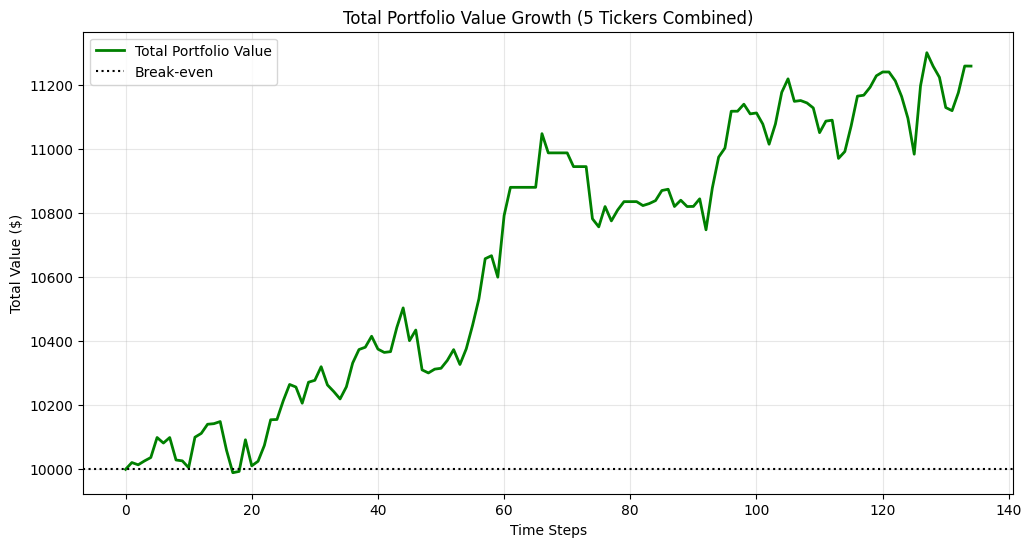

In [51]:
import matplotlib.pyplot as plt

# 1. 초기 설정
initial_total_cash = 10000
num_tickers = len(tickers_5)
cash_per_ticker = initial_total_cash / num_tickers
portfolio = {ticker: {'cash': cash_per_ticker, 'shares': 0} for ticker in tickers_5}

# 2. 데이터 역변환 및 준비
processed_data = {}
for ticker in tickers_5:
    # 2D 배열을 1D로 변환하여 처리하기 쉽게 만듦
    actual_prices = target_scalers[ticker].inverse_transform(actual[ticker]).flatten()
    pred_prices = target_scalers[ticker].inverse_transform(predictions[ticker]).flatten()
    processed_data[ticker] = {
        'actual': actual_prices, 
        'pred': pred_prices,
        'history_cash': [],
        'history_shares': []
    }

# 3. 일자별(Time Step) 병렬 시뮬레이션
num_steps = len(processed_data[tickers_5[0]]['actual'])
total_value_history = []

for i in range(num_steps):
    day_total_value = 0
    
    for ticker in tickers_5:
        price = processed_data[ticker]['actual'][i]
        pred = processed_data[ticker]['pred'][i]
        previous = processed_data[ticker]['actual'][i-1] if i > 0 else price
        
        dif = ((pred - previous) / previous) * 100

        # --- 가중치 기반 거래량 조절 로직 ---
        if dif > 0.05:  # 매수 신호
            # dif 값에 따라 투자 비중(ratio) 결정 (예: 최대 0.5%일 때 100% 투자)
            # 여기서는 간단한 3단계 threshold 예시를 사용합니다.
            if dif < 0.2:
                invest_ratio = 0.3  # 가용 현금의 30%
            elif dif < 0.5:
                invest_ratio = 0.6  # 가용 현금의 60%
            else:
                invest_ratio = 1.0  # 가용 현금의 100% (Full Bet)

            # 해당 종목에 할당된 현금 중 비율만큼만 사용하여 매수
            available_cash = portfolio[ticker]['cash'] * invest_ratio
            if available_cash > price:
                buy_shares = available_cash // price
                portfolio[ticker]['shares'] += buy_shares
                portfolio[ticker]['cash'] -= buy_shares * price
                print(f"Day {i} | Buying {ticker}: {buy_shares} shares, Dif: {dif:.3f}%, Cash : {portfolio[ticker]['cash']}")

        elif dif < -0.05:  # 매도 신호
            if portfolio[ticker]['shares'] > 0:
                portfolio[ticker]['cash'] += portfolio[ticker]['shares'] * price
                print(f"Day {i} | Selling {ticker}: {portfolio[ticker]['shares']} shares, Cash : {portfolio[ticker]['cash']}")
                portfolio[ticker]['shares'] = 0
        
        # 가치 합산
        day_total_value += portfolio[ticker]['cash'] + (portfolio[ticker]['shares'] * price)

    total_value_history.append(day_total_value)

# 4. 개별 종목 그래프 출력
for ticker in tickers_5:
    plt.figure(figsize=(12, 5))
    plt.plot(processed_data[ticker]['actual'], label='Actual Price', color='blue', alpha=0.6)
    plt.plot(processed_data[ticker]['pred'], label='Predicted Price', color='red', linestyle='--', alpha=0.7)
    
    plt.title(f"[{ticker}] Actual vs Prediction")
    plt.xlabel("Time Steps")
    plt.ylabel("Price ($)")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

# 5. 전체 포트폴리오 성과 요약
final_val = total_value_history[-1]
print(f"--- 최종 결과 요약 ---")
print(f"초기 자본: ${initial_total_cash}")
print(f"최종 자산: ${final_val:.2f}")
print(f"누적 수익률: {((final_val - initial_total_cash) / initial_total_cash) * 100:.2f}%")

# 6. 전체 포트폴리오 가치 변화 그래프
plt.figure(figsize=(12, 6))
plt.plot(total_value_history, label='Total Portfolio Value', color='green', linewidth=2)
plt.axhline(y=initial_total_cash, color='black', linestyle=':', label='Break-even')
plt.title("Total Portfolio Value Growth (5 Tickers Combined)")
plt.xlabel("Time Steps")
plt.ylabel("Total Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()